In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# Utility helpers
def fmt_m(v):
    return f"{v/1e6:.2f}M"

def styled_table(ax, data, col_labels, col_widths=None, header_color='#2c7bb6'):
    ax.axis('off')
    if col_widths is None:
        col_widths = [1/len(col_labels)] * len(col_labels)
    tbl = ax.table(cellText=data, colLabels=col_labels,
                   cellLoc='center', loc='center', colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.7)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if r == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#f0f6fb')
    return tbl

def metric_cards(ax, items):
    ax.axis('off')
    n = len(items)
    card_w = 1.0 / n
    for i, (label, val, col) in enumerate(items):
        x = i * card_w
        rect = mpatches.FancyBboxPatch((x+0.015, 0.08), card_w-0.03, 0.84,
                                        transform=ax.transAxes, clip_on=False,
                                        boxstyle='round,pad=0.03',
                                        facecolor=col, edgecolor='none')
        ax.add_patch(rect)
        ax.text(x+card_w/2, 0.62, str(val), ha='center', va='center',
                transform=ax.transAxes, color='white', fontsize=13, fontweight='bold')
        ax.text(x+card_w/2, 0.25, label, ha='center', va='center',
                transform=ax.transAxes, color='white', fontsize=9, alpha=0.9)


# Smartphone Price Prediction
### Supervised Machine Learning — Regression Pipeline

> **Problem:** Xây dựng mô hình Regression dự đoán giá smartphone tại thị trường Việt Nam dựa trên thông số kỹ thuật.
> **Target:** `price_vnd` — Giá bán công khai hiện tại tại thời điểm thu thập trên FPT Shop, không gồm trade-in, voucher cá nhân, trả góp hoặc ưu đãi có điều kiện.
> **Data Source:** FPT Shop · **Final Model:** Ridge Regression · **sklearn version:** See cell below.

In [2]:
import sklearn
print(f"Python: {__import__('sys').version.split()[0]}  |  "
      f"scikit-learn: {sklearn.__version__}  |  "
      f"pandas: {pd.__version__}  |  numpy: {np.__version__}")


Python: 3.13.9  |  scikit-learn: 1.9.0  |  pandas: 3.0.5  |  numpy: 2.5.1


---
## 1. Executive Summary

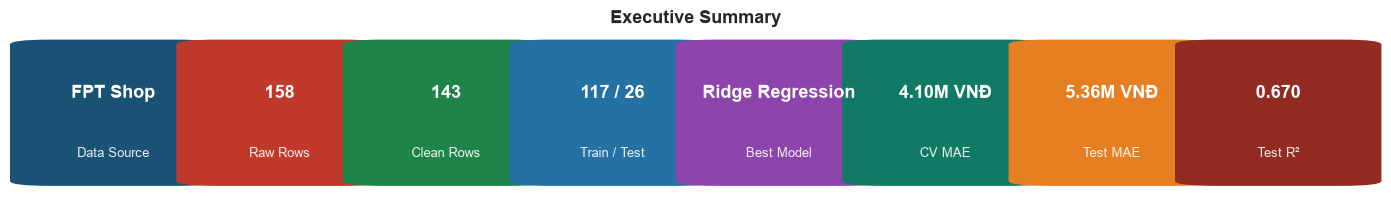

In [3]:
df_clean = pd.read_csv('data/processed/fptshop_smartphones_clean.csv')
df_raw   = pd.read_csv('data/raw/fptshop_smartphones.csv')
df_comp  = pd.read_csv('data/processed/model_comparison.csv').sort_values('CV MAE')
df_pred  = pd.read_csv('data/processed/test_predictions.csv')
X_train  = pd.read_csv('data/processed/X_train.csv')
X_test   = pd.read_csv('data/processed/X_test.csv')
y_train  = pd.read_csv('data/processed/y_train.csv')['price_vnd']
y_test   = pd.read_csv('data/processed/y_test.csv')['price_vnd']
manifest = pd.read_csv('data/processed/split_manifest.csv')

# Recompute test metrics from artifact
test_mae  = df_pred['absolute_error'].mean()
test_rmse = np.sqrt((df_pred['actual_price'] - df_pred['predicted_price']).pow(2).mean())
ss_res = ((df_pred['actual_price'] - df_pred['predicted_price'])**2).sum()
ss_tot = ((df_pred['actual_price'] - df_pred['actual_price'].mean())**2).sum()
test_r2 = 1 - ss_res/ss_tot

best_row = df_comp.iloc[0]
cv_mae   = best_row['CV MAE']

items = [
    ('Data Source',  'FPT Shop',             '#1a5276'),
    ('Raw Rows',     str(len(df_raw)),        '#c0392b'),
    ('Clean Rows',   str(len(df_clean)),      '#1e8449'),
    ('Train / Test', f"{len(X_train)} / {len(X_test)}", '#2471a3'),
    ('Best Model',   'Ridge Regression',      '#8e44ad'),
    ('CV MAE',       fmt_m(cv_mae) + ' VNĐ', '#117a65'),
    ('Test MAE',     fmt_m(test_mae) + ' VNĐ','#e67e22'),
    ('Test R²',      f'{test_r2:.3f}',        '#922b21'),
]

fig, ax = plt.subplots(figsize=(14, 2.2))
metric_cards(ax, items)
ax.set_title('Executive Summary', fontsize=13, fontweight='bold', pad=6)
plt.tight_layout()
plt.show()


---
## 2. Problem Definition

| Dimension | Detail |
|---|---|
| **Task** | Regression |
| **Target** | `price_vnd` — Giá bán công khai hiện tại tại thời điểm thu thập, không gồm trade-in, voucher, trả góp |
| **Data Source** | FPT Shop (danh mục điện thoại) |
| **Unit** | VNĐ |
| **Scope** | Smartphone đang được bán tại FPT Shop |
| **Goal** | Dự đoán giá dựa trên thông số kỹ thuật cơ bản (RAM, Storage, Camera, v.v.) |

---
## 3. ML Pipeline Overview

Sơ đồ tổng quan các bước xử lý dữ liệu và huấn luyện mô hình.

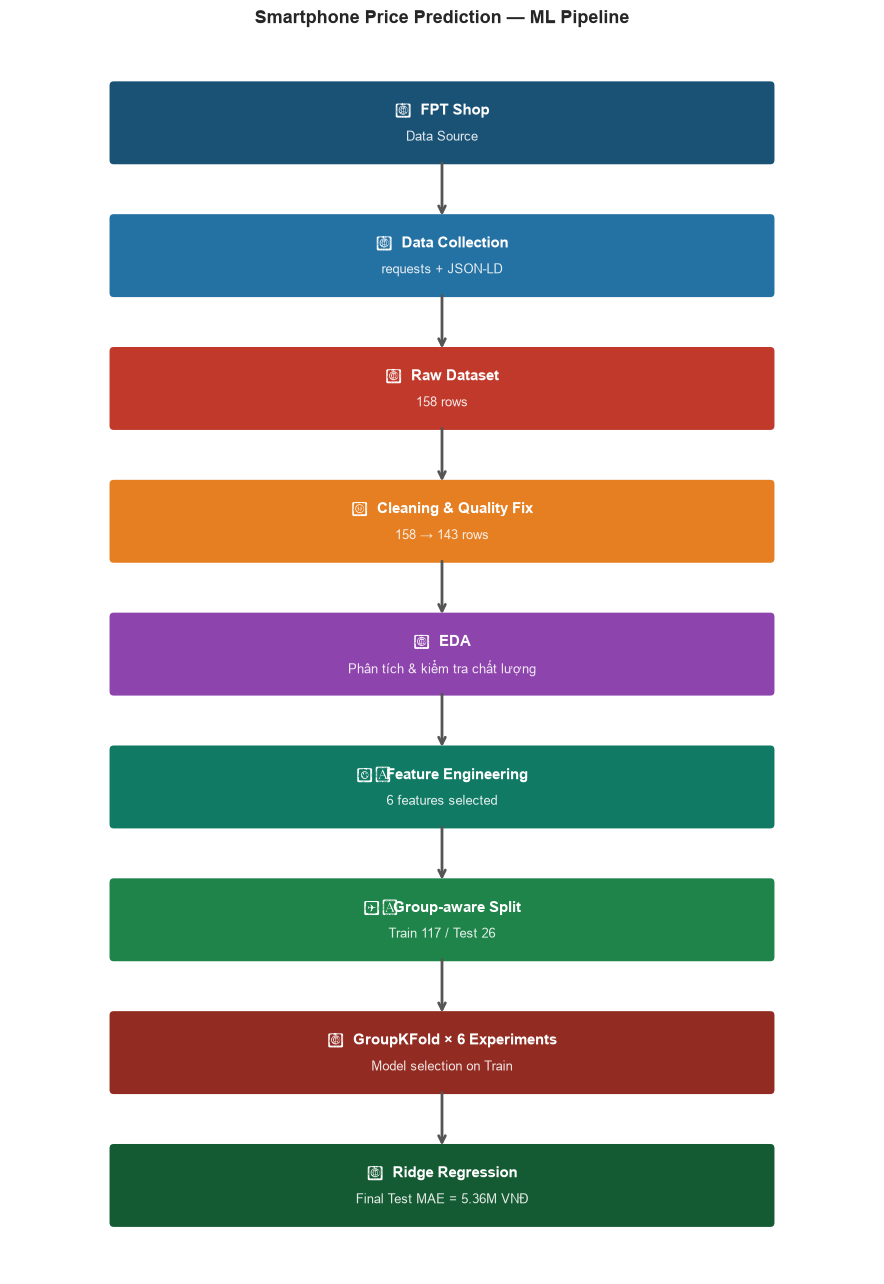

In [4]:
stages = [
    ('#1a5276', '🌐  FPT Shop',                  'Data Source'),
    ('#2471a3', '📥  Data Collection',            'requests + JSON-LD'),
    ('#c0392b', '📄  Raw Dataset',                f'{len(df_raw)} rows'),
    ('#e67e22', '🧹  Cleaning & Quality Fix',     f'{len(df_raw)} → {len(df_clean)} rows'),
    ('#8e44ad', '📊  EDA',                        'Phân tích & kiểm tra chất lượng'),
    ('#117a65', '⚙️   Feature Engineering',        '6 features selected'),
    ('#1e8449', '✂️   Group-aware Split',          f'Train {len(X_train)} / Test {len(X_test)}'),
    ('#922b21', '🔁  GroupKFold × 6 Experiments', 'Model selection on Train'),
    ('#145a32', '🏆  Ridge Regression',           f'Final Test MAE = {fmt_m(test_mae)} VNĐ'),
]

fig, ax = plt.subplots(figsize=(9, 13))
ax.set_xlim(0, 10); ax.set_ylim(0, 14); ax.axis('off')

for i, (color, title, sub) in enumerate(stages):
    y = 13.0 - i * 1.5
    rect = mpatches.FancyBboxPatch((1.2, y-0.42), 7.6, 0.84,
                                    boxstyle='round,pad=0.06',
                                    facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(5.0, y+0.14, title, ha='center', va='center', color='white',
            fontsize=11, fontweight='bold')
    ax.text(5.0, y-0.16, sub, ha='center', va='center', color='white',
            fontsize=9, alpha=0.88)
    if i < len(stages)-1:
        y_next = 13.0 - (i+1)*1.5
        ax.annotate('', xy=(5.0, y_next+0.42), xytext=(5.0, y-0.42),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))

ax.set_title('Smartphone Price Prediction — ML Pipeline', fontsize=13,
             fontweight='bold', pad=8)
plt.tight_layout()
plt.show()


---
## 4. Data Collection

**Phương pháp:** Gửi HTTP request đến từng product URL, parse `application/ld+json` (JSON-LD) để trích xuất thông tin.

| Field | Nguồn |
|---|---|
| `brand`, `model_name` | `brand.name`, `name` trong JSON-LD |
| `price_vnd` | `offers.price` |
| `ram_raw`, `storage_raw` | Spec table trong HTML |
| `screen_size_inch`, `main_camera_mp` | Spec table |
| `has_5g` | Sự xuất hiện của "5G" trong spec |

Discovery: Bắt đầu từ `/dien-thoai`, duyệt brand links, validate `@type = Product`.
*(Notebook này không crawl lại — dữ liệu đã được lưu trong `data/raw/`.)*

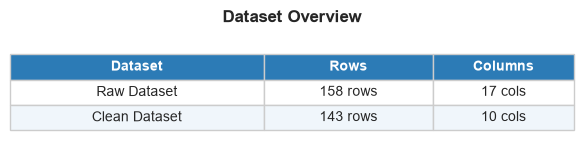

In [5]:
fig, ax = plt.subplots(figsize=(6, 1.8))
ax.axis('off')
data = [['Raw Dataset',   f'{len(df_raw)} rows',   f'{df_raw.shape[1]} cols'],
        ['Clean Dataset', f'{len(df_clean)} rows', f'{df_clean.shape[1]} cols']]
styled_table(ax, data, ['Dataset', 'Rows', 'Columns'], col_widths=[0.45, 0.3, 0.25])
ax.set_title('Dataset Overview', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout()
plt.show()


---
## 5. Dataset Overview

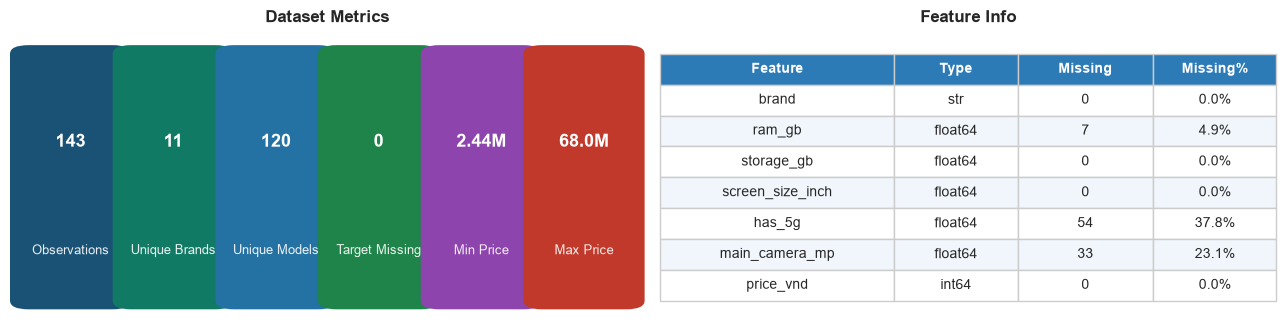

In [6]:
feat_cols = ['brand','ram_gb','storage_gb','screen_size_inch','has_5g','main_camera_mp','price_vnd']

metrics_items = [
    ('Observations',   str(len(df_clean)),              '#1a5276'),
    ('Unique Brands',  str(df_clean['brand'].nunique()), '#117a65'),
    ('Unique Models',  str(df_clean['model_name'].nunique()), '#2471a3'),
    ('Target Missing', str(int(df_clean['price_vnd'].isnull().sum())), '#1e8449'),
    ('Min Price',      f"{df_clean['price_vnd'].min()/1e6:.2f}M", '#8e44ad'),
    ('Max Price',      f"{df_clean['price_vnd'].max()/1e6:.1f}M", '#c0392b'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
metric_cards(axes[0], metrics_items)
axes[0].set_title('Dataset Metrics', fontsize=12, fontweight='bold', pad=6)

feat_data = [[c, str(df_clean[c].dtype),
              str(int(df_clean[c].isnull().sum())),
              f"{df_clean[c].isnull().mean()*100:.1f}%"] for c in feat_cols]
styled_table(axes[1], feat_data, ['Feature','Type','Missing','Missing%'],
             col_widths=[0.38, 0.2, 0.22, 0.2])
axes[1].set_title('Feature Info', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout()
plt.show()


In [7]:
display_cols = ['brand','model_name','ram_gb','storage_gb',
                'screen_size_inch','has_5g','main_camera_mp','price_vnd']
df_clean[display_cols].head()


,brand,model_name,ram_gb,storage_gb,screen_size_inch,has_5g,main_camera_mp,price_vnd
0,Oppo,OPPO Reno15 5G 12GB,12.00,256.00,6.59,1.00,50.00,16990000
1,Apple,iPhone 16,8.00,128.00,6.10,NaN,NaN,20990000
2,Samsung,Samsung Galaxy S25 FE 5G,8.00,128.00,6.70,1.00,50.00,13090000
3,Xiaomi,Xiaomi 17 Ultra 5G 16GB,16.00,512.00,6.90,1.00,50.00,31990000
4,Samsung,Samsung Galaxy S26 5G 12GB,12.00,256.00,6.30,1.00,50.00,20990000


---
## 6. Data Cleaning

Các bước xử lý chính:
1. `price_vnd <= 0` hoặc missing → **Remove** (invalid target).
2. **Duplicate audit** — Exact duplicate rows bị xoá; trùng URL được kiểm tra theo cặp.
3. **RAM parsing** — Chuỗi `"8 GB"` → `ram_gb = 8.0`; hỗ trợ cả MB (512 MB → 0.5 GB).
4. **Storage / Screen / Camera parsing** — Extract số thực từ chuỗi.
5. Feature 100% missing (`chipset`, `refresh_rate`, `release_year`) bị **DROP**.

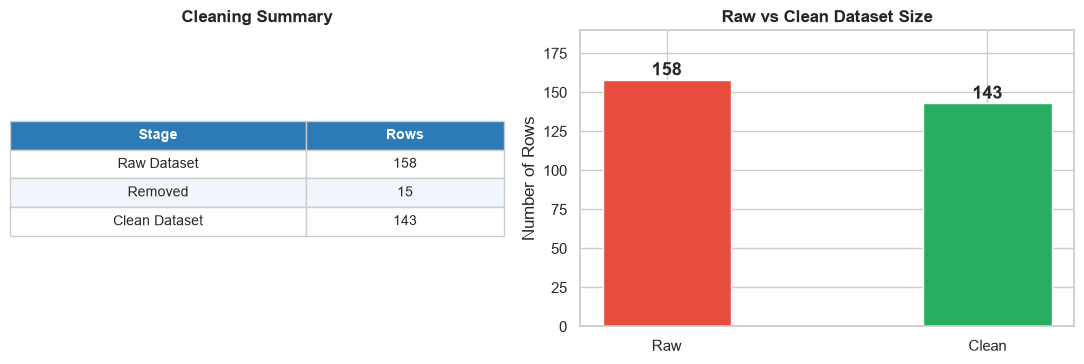

In [8]:
raw_n, clean_n = len(df_raw), len(df_clean)
removed = raw_n - clean_n

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Table
tdata = [['Raw Dataset', str(raw_n)], ['Removed', str(removed)], ['Clean Dataset', str(clean_n)]]
styled_table(axes[0], tdata, ['Stage', 'Rows'], col_widths=[0.6, 0.4])
axes[0].set_title('Cleaning Summary', fontsize=12, fontweight='bold', pad=6)

# Bar chart
bars = axes[1].bar(['Raw', 'Clean'], [raw_n, clean_n],
                   color=['#e74c3c', '#27ae60'], width=0.4)
for bar, val in zip(bars, [raw_n, clean_n]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, raw_n * 1.2)
axes[1].set_ylabel('Number of Rows')
axes[1].set_title('Raw vs Clean Dataset Size', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


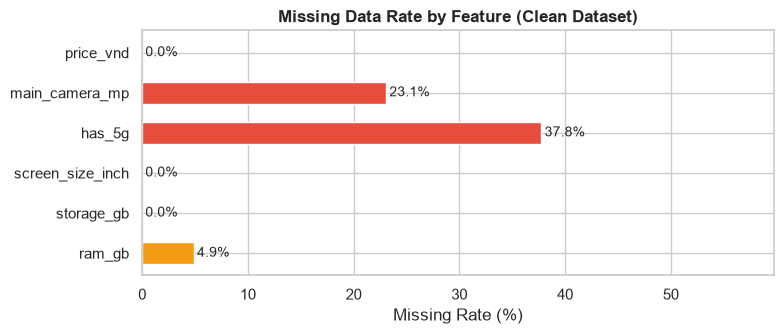

In [9]:
# Missing rate chart
miss_feat = ['ram_gb','storage_gb','screen_size_inch','has_5g','main_camera_mp','price_vnd']
miss_pct  = [df_clean[c].isnull().mean()*100 for c in miss_feat]
colors_m  = ['#2ecc71' if v == 0 else '#f39c12' if v < 20 else '#e74c3c' for v in miss_pct]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(miss_feat, miss_pct, color=colors_m, height=0.55)
for bar, val in zip(bars, miss_pct):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Data Rate by Feature (Clean Dataset)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(miss_pct)*1.45+5)
plt.tight_layout()
plt.show()


**Key Takeaway:** `price_vnd` không có missing values (target đủ để train). `has_5g` thiếu nhiều nhất (~38%), sẽ được xử lý bằng categorical *Unknown* trong preprocessing.

---
## 7. Data Quality Correction — Mini Case Study

Phát hiện và sửa lỗi parsing trong Phase 4 (EDA).

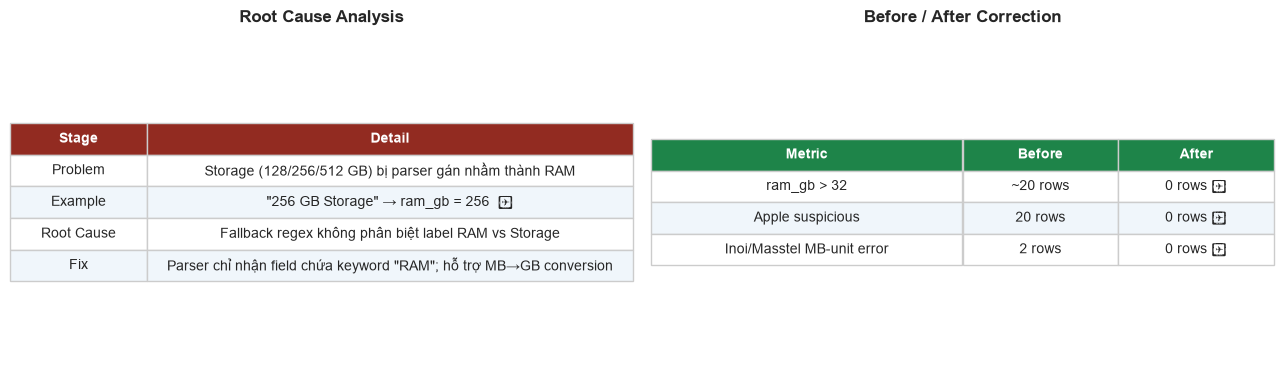

In [10]:
case_data = [
    ['Problem',    'Storage (128/256/512 GB) bị parser gán nhầm thành RAM'],
    ['Example',    '"256 GB Storage" → ram_gb = 256  ❌'],
    ['Root Cause', 'Fallback regex không phân biệt label RAM vs Storage'],
    ['Fix',        'Parser chỉ nhận field chứa keyword "RAM"; hỗ trợ MB→GB conversion'],
]

before_after = [
    ['ram_gb > 32', '~20 rows', '0 rows ✅'],
    ['Apple suspicious', '20 rows', '0 rows ✅'],
    ['Inoi/Masstel MB-unit error', '2 rows', '0 rows ✅'],
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

styled_table(axes[0], case_data, ['Stage', 'Detail'],
             col_widths=[0.22, 0.78], header_color='#922b21')
axes[0].set_title('Root Cause Analysis', fontsize=12, fontweight='bold', pad=6)

styled_table(axes[1], before_after, ['Metric', 'Before', 'After'],
             col_widths=[0.5, 0.25, 0.25], header_color='#1e8449')
axes[1].set_title('Before / After Correction', fontsize=12, fontweight='bold', pad=6)

plt.tight_layout()
plt.show()


**Lesson Learned:** EDA không chỉ là công cụ tạo biểu đồ — đây là bước kiểm tra chất lượng Data Pipeline. Mô hình huấn luyện trên dữ liệu sai sẽ không cho kết quả đáng tin cậy dù thuật toán có tốt đến đâu.

---
## 8. Exploratory Data Analysis

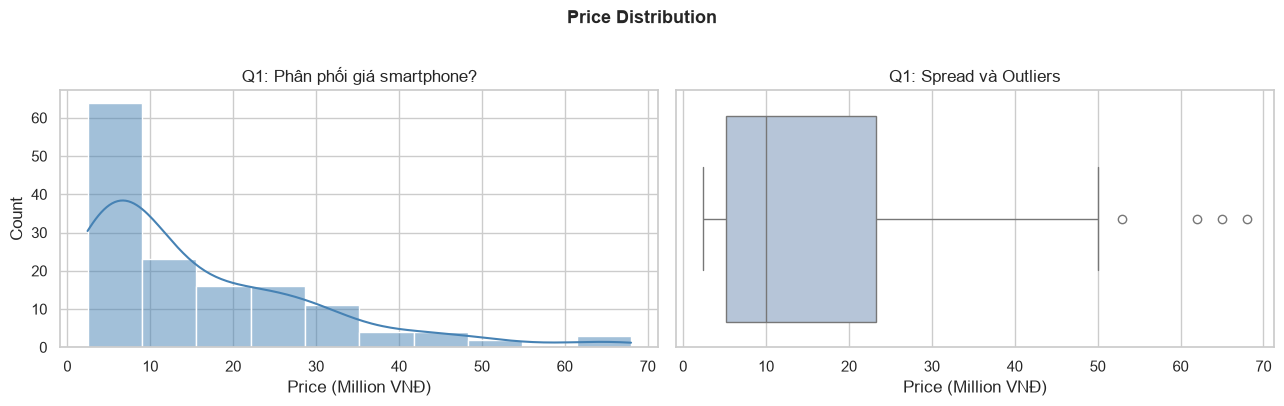

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_clean['price_vnd']/1e6, kde=True, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Price (Million VNĐ)'); axes[0].set_ylabel('Count')
axes[0].set_title('Q1: Phân phối giá smartphone?')

sns.boxplot(x=df_clean['price_vnd']/1e6, ax=axes[1], color='lightsteelblue')
axes[1].set_xlabel('Price (Million VNĐ)')
axes[1].set_title('Q1: Spread và Outliers')

plt.suptitle('Price Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


**Quan sát:** `price_vnd` lệch phải đáng kể. Phần lớn điện thoại trong dataset có giá dưới 15 triệu; một số thiết bị cao cấp kéo dài đến 68 triệu, tạo khoảng cách lớn giữa median (~10M) và mean (~15.8M).

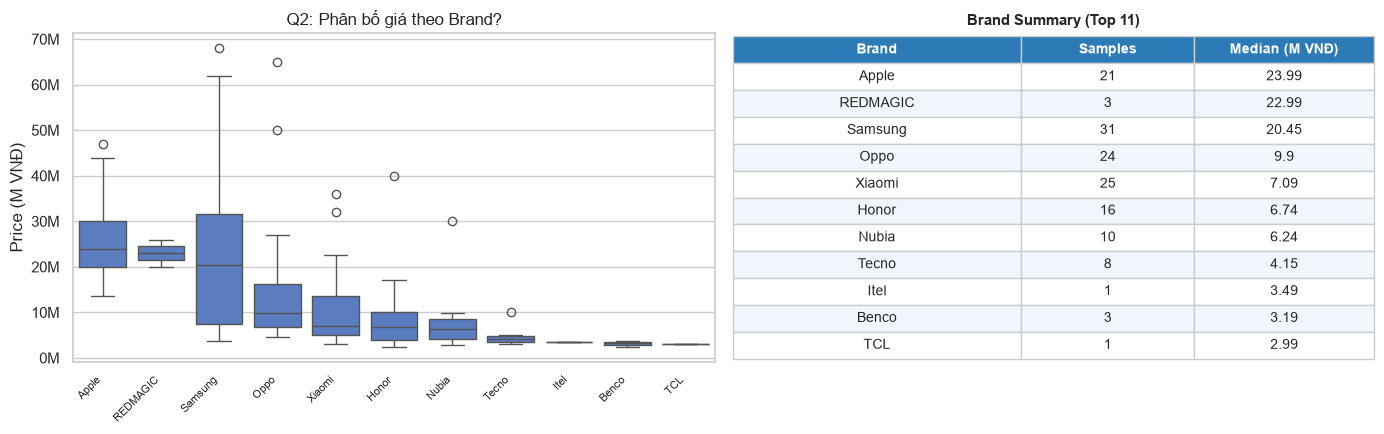

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
order = df_clean.groupby('brand')['price_vnd'].median().sort_values(ascending=False).index
sns.boxplot(x='brand', y='price_vnd', data=df_clean, order=order, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[0].set_title('Q2: Phân bố giá theo Brand?'); axes[0].set_ylabel('Price (M VNĐ)'); axes[0].set_xlabel('')

brand_stats = df_clean.groupby('brand').agg(Samples=('price_vnd','count'),
                                             Median=('price_vnd','median')).reset_index()
brand_stats['Median (M)'] = (brand_stats['Median']/1e6).round(2)
brand_stats = brand_stats.sort_values('Median', ascending=False)
bdata = brand_stats[['brand','Samples','Median (M)']].head(11).values.tolist()
bdata = [[str(x) for x in row] for row in bdata]
styled_table(axes[1], bdata, ['Brand','Samples','Median (M VNĐ)'],
             col_widths=[0.45, 0.27, 0.28])
axes[1].set_title('Brand Summary (Top 11)', fontsize=11, fontweight='bold', pad=6)
plt.tight_layout(); plt.show()


**Quan sát:** Trong dataset hiện tại, Apple có xu hướng tập trung nhiều hơn ở phân khúc giá cao. Samsung có dải giá rộng từ phổ thông đến cao cấp. Đây là tương quan quan sát được trong dữ liệu, không kết luận quan hệ nhân quả.

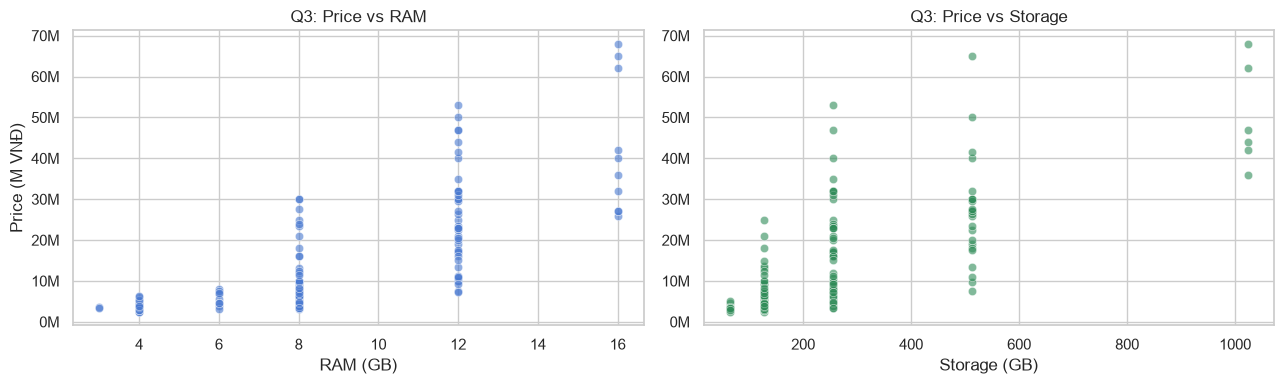

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x='ram_gb', y='price_vnd', data=df_clean, ax=axes[0], alpha=0.6)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[0].set_title('Q3: Price vs RAM'); axes[0].set_xlabel('RAM (GB)'); axes[0].set_ylabel('Price (M VNĐ)')

sns.scatterplot(x='storage_gb', y='price_vnd', data=df_clean, ax=axes[1], alpha=0.6, color='seagreen')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[1].set_title('Q3: Price vs Storage'); axes[1].set_xlabel('Storage (GB)'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()


**Quan sát:** RAM và Storage có xu hướng dương với giá bán. Tuy nhiên phương sai lớn ở mức RAM 8–12 GB cho thấy RAM không đủ để phân biệt tầm giá — phản ánh sự vắng mặt của thông tin chipset và generation trong feature set.

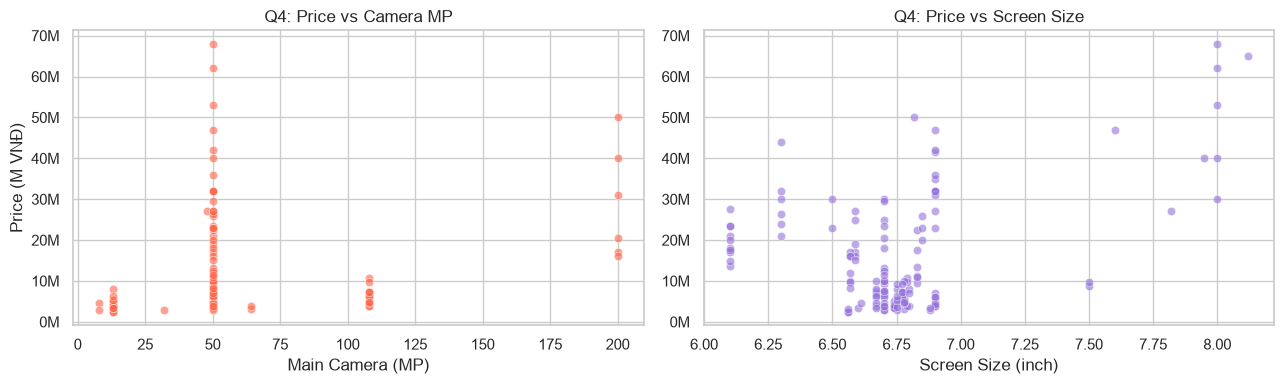

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_cam = df_clean.dropna(subset=['main_camera_mp'])
sns.scatterplot(x='main_camera_mp', y='price_vnd', data=df_cam, ax=axes[0], alpha=0.6, color='tomato')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[0].set_title('Q4: Price vs Camera MP'); axes[0].set_xlabel('Main Camera (MP)'); axes[0].set_ylabel('Price (M VNĐ)')

sns.scatterplot(x='screen_size_inch', y='price_vnd', data=df_clean, ax=axes[1], alpha=0.6, color='mediumpurple')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[1].set_title('Q4: Price vs Screen Size'); axes[1].set_xlabel('Screen Size (inch)'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()


**Quan sát:** Camera MP cho thấy tương quan yếu với giá. Nhiều điện thoại phổ thông giá thấp cũng có camera 50–108 MP, trong khi các flagship cao giá nhờ chất lượng hệ thống camera hơn là số MP đơn thuần. Screen size có tương quan nhẹ dương.

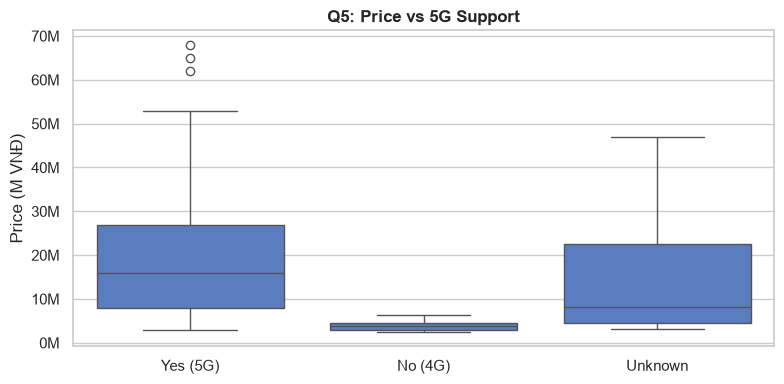

In [15]:
df_5g = df_clean.copy()
df_5g['5G Status'] = df_5g['has_5g'].apply(lambda v:
    'Yes (5G)' if v==1.0 else 'No (4G)' if v==0.0 else 'Unknown')

fig, ax = plt.subplots(figsize=(8, 4))
order_5g = ['Yes (5G)', 'No (4G)', 'Unknown']
sns.boxplot(x='5G Status', y='price_vnd', data=df_5g, order=order_5g, ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
ax.set_title('Q5: Price vs 5G Support', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (M VNĐ)'); ax.set_xlabel('')
plt.tight_layout(); plt.show()


**Quan sát:** Điện thoại có 5G trong dataset có xu hướng giá cao hơn nhóm 4G. Tuy nhiên nhóm Unknown chiếm số lượng lớn (~38%), tạo ra sự không chắc chắn trong phân tích này.

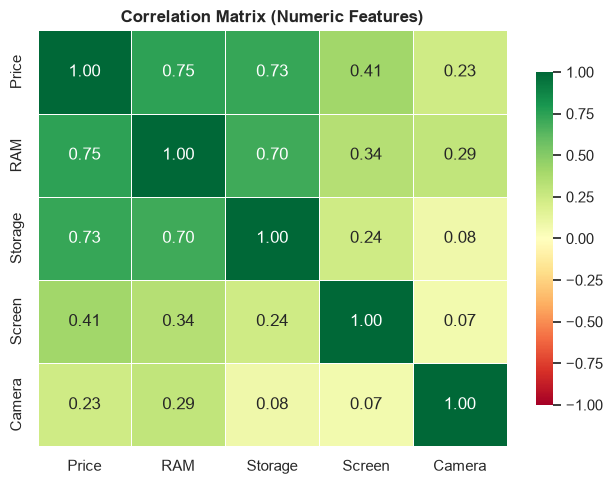

In [16]:
num_cols = ['price_vnd','ram_gb','storage_gb','screen_size_inch','main_camera_mp']
corr = df_clean[num_cols].corr()
labels = ['Price','RAM','Storage','Screen','Camera']
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            ax=ax, xticklabels=labels, yticklabels=labels,
            linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix (Numeric Features)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


**Key Takeaway — EDA:** Storage và RAM là hai numerical features có xu hướng tương quan dương rõ nhất với `price_vnd`. Camera MP cho signal yếu hơn kỳ vọng. Brand là categorical feature phân tầng giá đáng kể.

---
## 9. Feature Selection

| Feature | Type | Quyết định |
|---|---|---|
| `brand` | Categorical | ✅ Giữ — phân tầng giá theo thương hiệu |
| `ram_gb` | Numeric | ✅ Giữ — xu hướng tương quan dương |
| `storage_gb` | Numeric | ✅ Giữ — xu hướng tương quan dương |
| `screen_size_inch` | Numeric | ✅ Giữ — signal nhẹ |
| `has_5g` | Categorical | ✅ Giữ — phân tầng tier sản phẩm |
| `main_camera_mp` | Numeric | ✅ Giữ — dù signal yếu, không loại bỏ V1 |
| `model_name` | String | ❌ Loại — high cardinality, nguy cơ memorization |
| `product_url`, `collected_at` | String | ❌ Loại — metadata không có giá trị học máy |

---
## 10. Feature Engineering & Preprocessing

**Missing Data Strategy:**

| Feature | Strategy |
|---|---|
| `ram_gb` | Median Imputation + Missing Indicator |
| `main_camera_mp` | Median Imputation + Missing Indicator |
| `has_5g` | Map → categorical string: `"Yes"` / `"No"` / `"Unknown"` + OneHotEncoder |

**Preprocessing Architecture:**

```
Numeric (ram_gb, storage_gb, screen_size_inch, main_camera_mp)
    → SimpleImputer(strategy='median', add_indicator=True)
    → StandardScaler  [chỉ với Linear/Ridge Pipeline]

Categorical (brand, has_5g)
    → OneHotEncoder(handle_unknown='ignore')

→ ColumnTransformer → Regressor
```

Toàn bộ preprocessing được đóng gói trong `sklearn Pipeline/ColumnTransformer`. Lệnh `.fit()` chỉ được gọi trên tập Train.

---
## 11. Group-aware Data Split

**Vấn đề với Random Split:**

```
iPhone 16 128GB  ┐
iPhone 16 256GB  ├──→ model_family = "iphone 16" → ALL variants vào cùng Train HOẶC Test
iPhone 16 512GB  ┘
```

Nếu dùng random split, các biến thể của cùng dòng máy có thể bị chia vào cả hai tập, khiến model "học vẹt" giá nền của dòng máy — đây là dạng Data Leakage ngầm.

**Giải pháp:** `GroupShuffleSplit(test_size=0.2, random_state=42)` với group key = `model_family`
(loại bỏ dung lượng và connectivity suffix khỏi `model_name`).

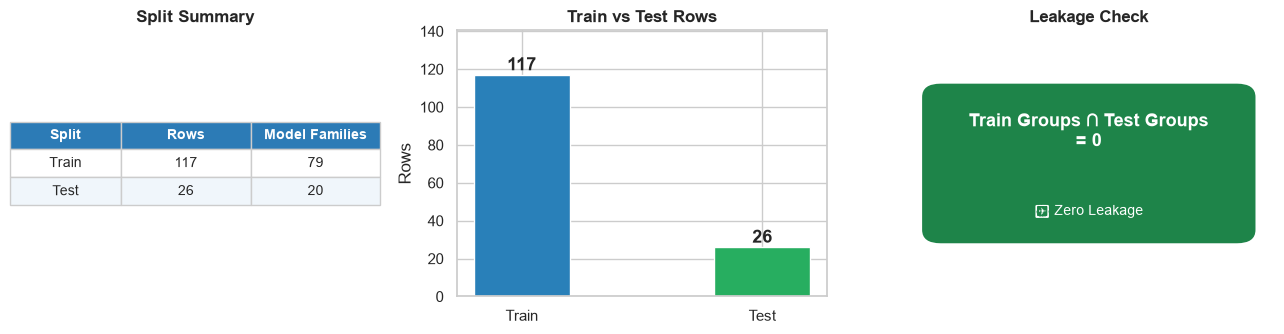

In [17]:
train_m = manifest[manifest['split']=='train']
test_m  = manifest[manifest['split']=='test']
g_train = set(train_m['model_family'])
g_test  = set(test_m['model_family'])
overlap = g_train & g_test

split_data = [
    ['Train', str(len(X_train)), str(len(g_train))],
    ['Test',  str(len(X_test)),  str(len(g_test))],
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

styled_table(axes[0], split_data, ['Split', 'Rows', 'Model Families'],
             col_widths=[0.3, 0.35, 0.35])
axes[0].set_title('Split Summary', fontsize=12, fontweight='bold', pad=6)

bars = axes[1].bar(['Train', 'Test'], [len(X_train), len(X_test)],
                   color=['#2980b9', '#27ae60'], width=0.4)
for bar, val in zip(bars, [len(X_train), len(X_test)]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, len(X_train)*1.2)
axes[1].set_ylabel('Rows')
axes[1].set_title('Train vs Test Rows', fontsize=12, fontweight='bold')

axes[2].axis('off')
overlap_msg = f"Train Groups ∩ Test Groups\n= {len(overlap)}"
color_box = '#1e8449' if len(overlap)==0 else '#c0392b'
rect = mpatches.FancyBboxPatch((0.1, 0.25), 0.8, 0.5,
                                transform=axes[2].transAxes, clip_on=False,
                                boxstyle='round,pad=0.05', facecolor=color_box, edgecolor='none')
axes[2].add_patch(rect)
axes[2].text(0.5, 0.62, overlap_msg, ha='center', va='center',
             transform=axes[2].transAxes, color='white', fontsize=13, fontweight='bold')
check = '✅ Zero Leakage' if len(overlap)==0 else '⚠️ Leakage Detected'
axes[2].text(0.5, 0.32, check, ha='center', va='center',
             transform=axes[2].transAxes, color='white', fontsize=10)
axes[2].set_title('Leakage Check', fontsize=12, fontweight='bold', pad=6)

plt.tight_layout(); plt.show()


**Key Takeaway:** GroupShuffleSplit đảm bảo tất cả biến thể của cùng một dòng máy nằm cố định về một phía. Overlap = 0 nghĩa là Test Set chứa các dòng máy mà model chưa từng thấy trong quá trình training — đây là điều kiện đánh giá trung thực.

---
## 12. Validation Strategy

| Set | Mục đích |
|---|---|
| **Train (117 rows)** | Model selection qua `GroupKFold(n_splits=5)` |
| **Test (26 rows)** | Final evaluation — chỉ mở **đúng 1 lần** sau khi đã chọn model |

**Quy tắc cứng:** Test Set không được dùng để chọn model, hyperparameter hay target strategy.

Cross-validation: Mỗi fold, group overlap = 0.

---
## 13. Models & Target Strategies

**3 Model Families:**
- **Linear Regression** — Linear baseline chuẩn mực.
- **Ridge Regression** — Linear + L2 Regularization (giảm nhạy cảm với đa cộng tuyến).
- **Random Forest** — Tree-based nonlinear baseline.

**2 Target Strategies:** Mỗi model chạy trên cả hai strategy → **6 model-target experiments**.

| Strategy | Target | Inverse Transform |
|---|---|---|
| A (Raw) | `price_vnd` | Không cần |
| B (Log) | `log1p(price_vnd)` | `expm1(prediction)` |

Mọi metric cuối cùng đều tính trên đơn vị VNĐ.

---
## 14. Dummy Baseline

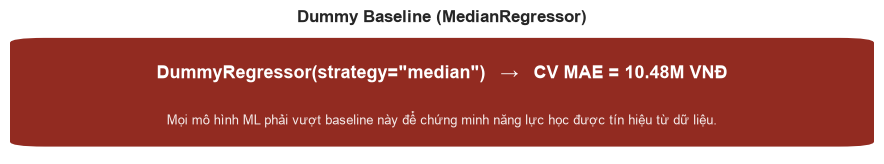

In [18]:
dummy_mae = 10475489

fig, ax = plt.subplots(figsize=(9, 1.8))
ax.axis('off')
rect = mpatches.FancyBboxPatch((0.04, 0.1), 0.92, 0.8, transform=ax.transAxes, clip_on=False,
                                boxstyle='round,pad=0.04', facecolor='#922b21', edgecolor='none')
ax.add_patch(rect)
ax.text(0.5, 0.65, f'DummyRegressor(strategy="median")   →   CV MAE = {dummy_mae/1e6:.2f}M VNĐ',
        ha='center', va='center', transform=ax.transAxes,
        color='white', fontsize=13, fontweight='bold')
ax.text(0.5, 0.28, 'Mọi mô hình ML phải vượt baseline này để chứng minh năng lực học được tín hiệu từ dữ liệu.',
        ha='center', va='center', transform=ax.transAxes, color='white', fontsize=9.5, alpha=0.9)
ax.set_title('Dummy Baseline (MedianRegressor)', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout(); plt.show()


---
## 15. Cross-Validation Results — 6 Model-Target Experiments

Kết quả `GroupKFold(n_splits=5)` trên Train Set. Tất cả metrics tính bằng VNĐ.

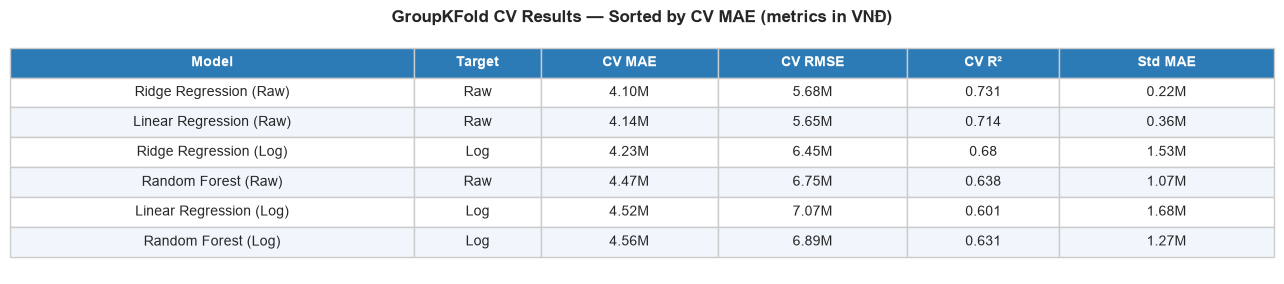

In [19]:
comp = pd.read_csv('data/processed/model_comparison.csv').sort_values('CV MAE').reset_index(drop=True)
comp_disp = comp.copy()
comp_disp['CV MAE']  = comp_disp['CV MAE'].apply(fmt_m)
comp_disp['CV RMSE'] = comp_disp['CV RMSE'].apply(fmt_m)
comp_disp['CV R²']   = comp_disp['CV R²'].round(3).astype(str)
comp_disp['Std MAE'] = comp_disp['Std MAE'].apply(fmt_m)
comp_disp = comp_disp[['Model','Target','CV MAE','CV RMSE','CV R²','Std MAE']]

fig, ax = plt.subplots(figsize=(13, 3))
table_data = comp_disp.values.tolist()
styled_table(ax, table_data,
             list(comp_disp.columns),
             col_widths=[0.32,0.1,0.14,0.15,0.12,0.17],
             header_color='#2c7bb6')
ax.set_title('GroupKFold CV Results — Sorted by CV MAE (metrics in VNĐ)', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout(); plt.show()


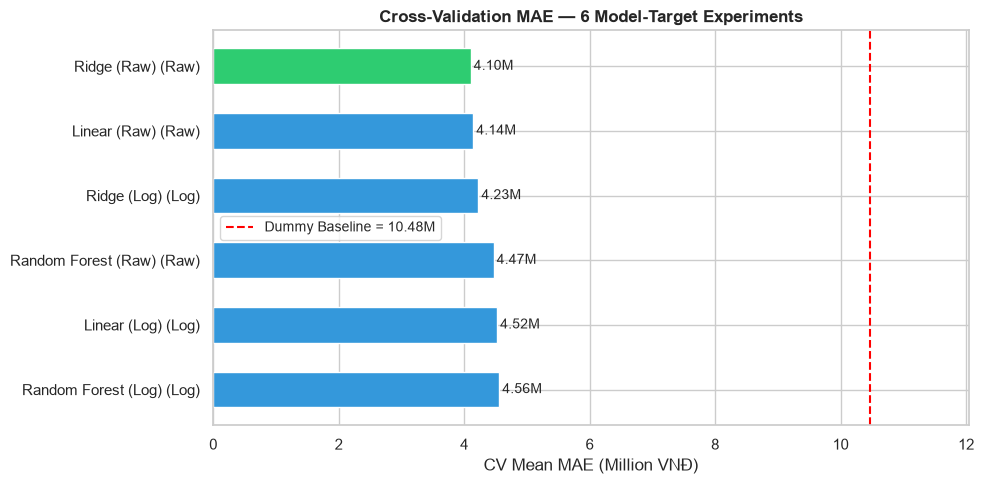

In [20]:
dummy_mae = 10475489

comp_plot = pd.read_csv('data/processed/model_comparison.csv').sort_values('CV MAE', ascending=False)
labels = comp_plot.apply(
    lambda r: r['Model'].replace(' Regression','').replace(' Regressor','') + f" ({r['Target']})", axis=1)
colors_bar = ['#2ecc71' if ('Ridge' in m and t=='Raw') else '#3498db'
              for m, t in zip(comp_plot['Model'], comp_plot['Target'])]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, comp_plot['CV MAE']/1e6, color=colors_bar, height=0.55)
for bar, val in zip(bars, comp_plot['CV MAE']):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{val/1e6:.2f}M', va='center', fontsize=10)
ax.axvline(dummy_mae/1e6, color='red', linestyle='--', linewidth=1.5,
           label=f'Dummy Baseline = {dummy_mae/1e6:.2f}M')
ax.set_xlabel('CV Mean MAE (Million VNĐ)')
ax.set_title('Cross-Validation MAE — 6 Model-Target Experiments', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, dummy_mae/1e6 * 1.15)
plt.tight_layout(); plt.show()


**Key Takeaway:** Ridge Regression (Raw target) đạt CV MAE thấp nhất và Std MAE ổn định nhất. Các cấu hình Log target không cải thiện MAE khi đổi ngược về VNĐ. Tất cả 6 cấu hình đều vượt Dummy Baseline (~10.5M) một cách có ý nghĩa.

---
## 16. Selected Model

| | |
|---|---|
| **Model** | Ridge Regression |
| **Regularization** | α = 1.0 (L2) |
| **Target Strategy** | Raw `price_vnd` |
| **Preprocessing** | Median Imputer + StandardScaler + OneHotEncoder |
| **Basis of selection** | Lowest CV MAE + Lowest Std MAE |

Model được chọn hoàn toàn dựa trên Train CV — không sử dụng Test Set.

---
## 17. Final Test Evaluation

Model Ridge (Raw) được fit trên toàn bộ 117 dòng Train, sau đó evaluate trên 26 dòng Test. Metrics được tính trực tiếp từ `test_predictions.csv`.

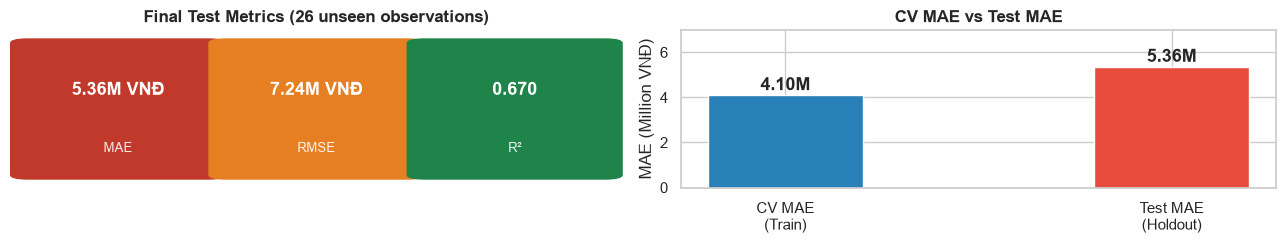

In [21]:
test_mae_v  = df_pred['absolute_error'].mean()
ss_res_v = ((df_pred['actual_price'] - df_pred['predicted_price'])**2).sum()
ss_tot_v = ((df_pred['actual_price'] - df_pred['actual_price'].mean())**2).sum()
test_rmse_v = np.sqrt(ss_res_v / len(df_pred))
test_r2_v   = 1 - ss_res_v/ss_tot_v

metric_items = [
    ('MAE',  fmt_m(test_mae_v)  + ' VNĐ', '#c0392b'),
    ('RMSE', fmt_m(test_rmse_v) + ' VNĐ', '#e67e22'),
    ('R²',   f'{test_r2_v:.3f}',           '#1e8449'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 2.6))
metric_cards(axes[0], metric_items)
axes[0].set_title('Final Test Metrics (26 unseen observations)', fontsize=12, fontweight='bold', pad=6)

cv_mae_v = pd.read_csv('data/processed/model_comparison.csv').sort_values('CV MAE').iloc[0]['CV MAE']
bars = axes[1].bar(['CV MAE\n(Train)', 'Test MAE\n(Holdout)'],
                   [cv_mae_v/1e6, test_mae_v/1e6],
                   color=['#2980b9', '#e74c3c'], width=0.4)
for bar, val in zip(bars, [cv_mae_v/1e6, test_mae_v/1e6]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(cv_mae_v, test_mae_v)/1e6 * 1.3)
axes[1].set_ylabel('MAE (Million VNĐ)')
axes[1].set_title('CV MAE vs Test MAE', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


**Quan sát:** Test MAE cao hơn CV MAE (~30%), phản ánh khả năng tổng quát hoá trên các dòng máy hoàn toàn chưa thấy (unseen model families) còn hạn chế. Với dataset 143 rows, đây là sampling variance bình thường — không kết luận overfitting chỉ từ hai con số này. R² = 0.67 cho thấy model đã bắt được signal có ý nghĩa.

---
## 18. Actual vs Predicted (Test Set)

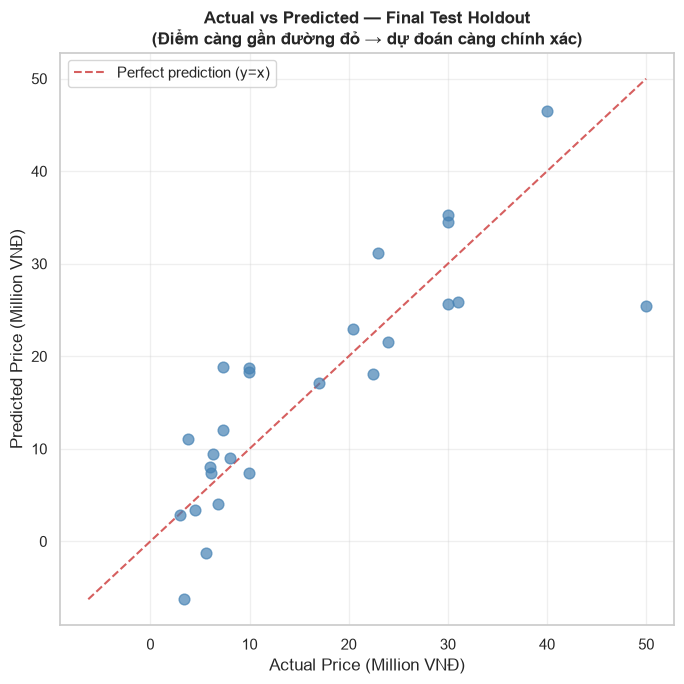

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_pred['actual_price']/1e6, df_pred['predicted_price']/1e6,
           alpha=0.7, color='steelblue', s=60, zorder=3)
min_v = min(df_pred['actual_price'].min(), df_pred['predicted_price'].min())/1e6
max_v = max(df_pred['actual_price'].max(), df_pred['predicted_price'].max())/1e6
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect prediction (y=x)')
ax.set_xlabel('Actual Price (Million VNĐ)'); ax.set_ylabel('Predicted Price (Million VNĐ)')
ax.set_title('Actual vs Predicted — Final Test Holdout\n(Điểm càng gần đường đỏ → dự đoán càng chính xác)',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## 19. Prediction Error Analysis

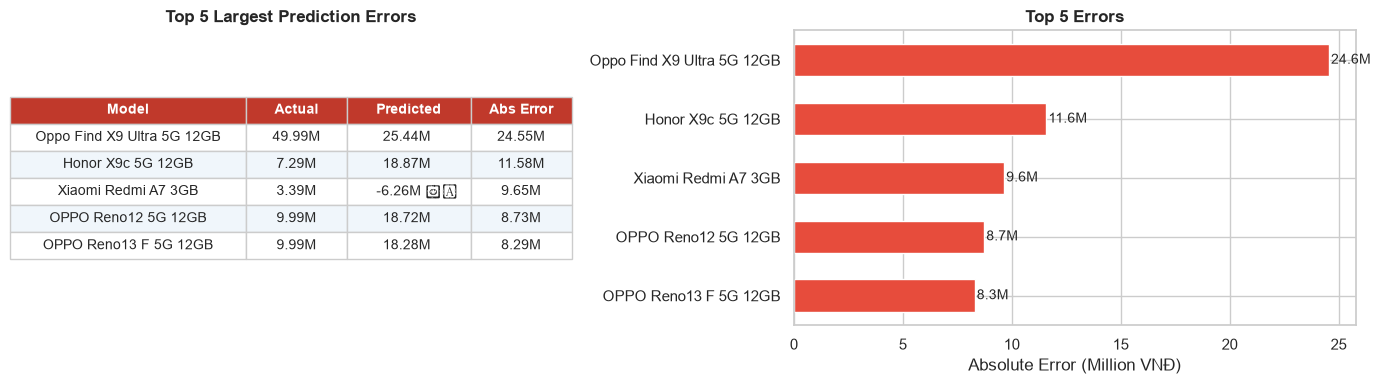

In [23]:
top5 = df_pred.sort_values('absolute_error', ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Table
t_data = [[row['model_name'],
           f"{row['actual_price']/1e6:.2f}M",
           f"{row['predicted_price']/1e6:.2f}M {'⚠️' if row['predicted_price']<0 else ''}",
           f"{row['absolute_error']/1e6:.2f}M"]
          for _, row in top5.iterrows()]
styled_table(axes[0], t_data, ['Model','Actual','Predicted','Abs Error'],
             col_widths=[0.42, 0.18, 0.22, 0.18], header_color='#c0392b')
axes[0].set_title('Top 5 Largest Prediction Errors', fontsize=12, fontweight='bold', pad=6)

# Horizontal bar
axes[1].barh(top5['model_name'], top5['absolute_error']/1e6, color='#e74c3c', height=0.55)
for i, (_, row) in enumerate(top5.iterrows()):
    axes[1].text(row['absolute_error']/1e6 + 0.1, i,
                 f"{row['absolute_error']/1e6:.1f}M", va='center', fontsize=10)
axes[1].set_xlabel('Absolute Error (Million VNĐ)')
axes[1].set_title('Top 5 Errors', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()


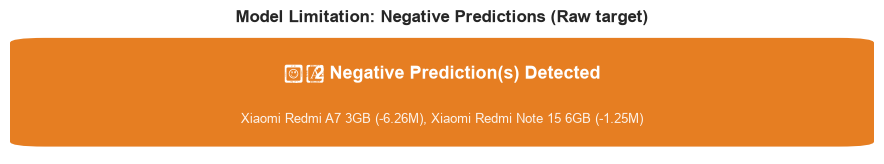

In [24]:
neg_preds = df_pred[df_pred['predicted_price'] < 0]
if len(neg_preds) > 0:
    fig, ax = plt.subplots(figsize=(9, 1.8))
    ax.axis('off')
    rect = mpatches.FancyBboxPatch((0.04, 0.1), 0.92, 0.8, transform=ax.transAxes, clip_on=False,
                                    boxstyle='round,pad=0.04', facecolor='#e67e22', edgecolor='none')
    ax.add_patch(rect)
    neg_list = ', '.join(f"{r['model_name']} ({r['predicted_price']/1e6:.2f}M)"
                         for _, r in neg_preds.iterrows())
    ax.text(0.5, 0.65, f'⚠️  {len(neg_preds)} Negative Prediction(s) Detected',
            ha='center', va='center', transform=ax.transAxes,
            color='white', fontsize=13, fontweight='bold')
    ax.text(0.5, 0.28, neg_list, ha='center', va='center',
            transform=ax.transAxes, color='white', fontsize=9.5, alpha=0.9)
    ax.set_title('Model Limitation: Negative Predictions (Raw target)', fontsize=12, fontweight='bold', pad=6)
    plt.tight_layout(); plt.show()


**Quan sát:** Oppo Find X9 Ultra (~50M) bị underpredict nặng nề vì model không có thông tin chipset hay tier sản phẩm. Các máy giá rẻ nhất bị overpredict — linear model trên raw target không có ràng buộc output > 0, có thể sinh ra giá trị âm khi ngoại suy ra ngoài vùng training.

---
## 20. Model V1 — Capabilities & Limitations

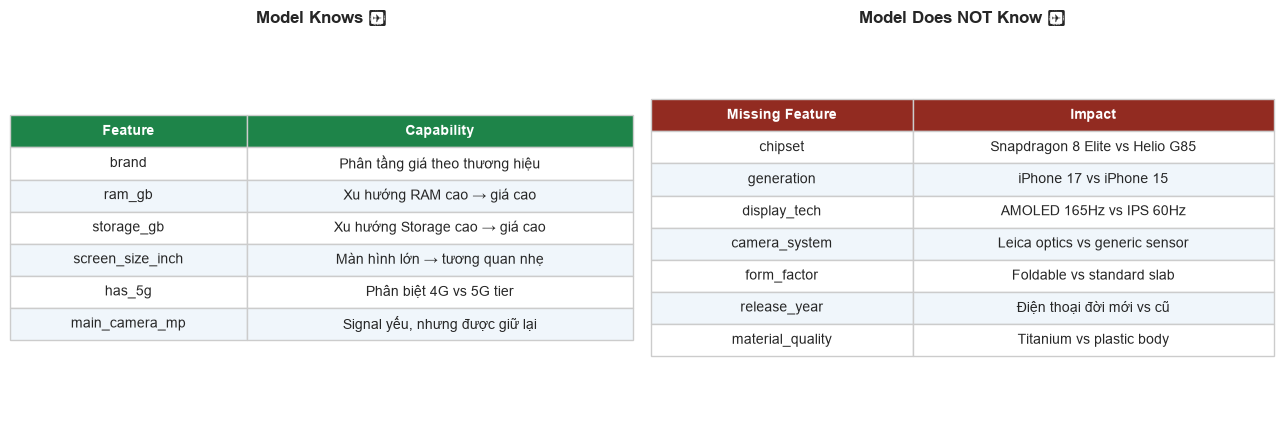

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

can_data = [
    ['brand', 'Phân tầng giá theo thương hiệu'],
    ['ram_gb', 'Xu hướng RAM cao → giá cao'],
    ['storage_gb', 'Xu hướng Storage cao → giá cao'],
    ['screen_size_inch', 'Màn hình lớn → tương quan nhẹ'],
    ['has_5g', 'Phân biệt 4G vs 5G tier'],
    ['main_camera_mp', 'Signal yếu, nhưng được giữ lại'],
]
styled_table(axes[0], can_data, ['Feature','Capability'], col_widths=[0.38,0.62], header_color='#1e8449')
axes[0].set_title('Model Knows ✅', fontsize=12, fontweight='bold', pad=6)

cant_data = [
    ['chipset',           'Snapdragon 8 Elite vs Helio G85'],
    ['generation',        'iPhone 17 vs iPhone 15'],
    ['display_tech',      'AMOLED 165Hz vs IPS 60Hz'],
    ['camera_system',     'Leica optics vs generic sensor'],
    ['form_factor',       'Foldable vs standard slab'],
    ['release_year',      'Điện thoại đời mới vs cũ'],
    ['material_quality',  'Titanium vs plastic body'],
]
styled_table(axes[1], cant_data, ['Missing Feature','Impact'], col_widths=[0.42,0.58], header_color='#922b21')
axes[1].set_title('Model Does NOT Know ❌', fontsize=12, fontweight='bold', pad=6)

plt.tight_layout(); plt.show()


**Kết luận:** Các lỗi prediction lớn nhất đều xuất phát từ việc model không phân biệt được flagship với mid-range khi các thông số cơ bản (RAM, Storage) tương đồng. Đây là structural limitation của feature set V1, không phải lỗi implementation.

---
## 21. Inference Demo

── Input Features ──


,brand,ram_gb,storage_gb,screen_size_inch,has_5g,main_camera_mp
0,Samsung,12.00,256.00,6.70,Yes,50.00


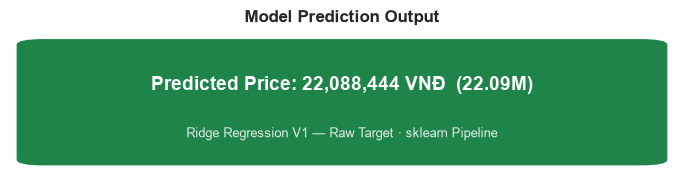

In [26]:
model = joblib.load('models/smartphone_price_model_v1.joblib')

demo_input = pd.DataFrame([{
    'brand':            'Samsung',
    'ram_gb':           12.0,
    'storage_gb':       256.0,
    'screen_size_inch': 6.7,
    'has_5g':           'Yes',
    'main_camera_mp':   50.0,
}])

print("── Input Features ──")
display(demo_input)

pred_vnd = model.predict(demo_input)[0]

fig, ax = plt.subplots(figsize=(7, 2.0))
ax.axis('off')
pred_color = '#1e8449' if pred_vnd > 0 else '#c0392b'
rect = mpatches.FancyBboxPatch((0.05, 0.1), 0.9, 0.8, transform=ax.transAxes, clip_on=False,
                                boxstyle='round,pad=0.04', facecolor=pred_color, edgecolor='none')
ax.add_patch(rect)
pred_label = f"Predicted Price: {pred_vnd:,.0f} VNĐ  ({pred_vnd/1e6:.2f}M)"
ax.text(0.5, 0.62, pred_label, ha='center', va='center',
        transform=ax.transAxes, color='white', fontsize=14, fontweight='bold')
if pred_vnd < 0:
    ax.text(0.5, 0.28, '⚠️  Warning: Negative prediction — Ridge V1 (Raw target) không có ràng buộc output > 0.',
            ha='center', va='center', transform=ax.transAxes, color='white', fontsize=9.5, alpha=0.9)
else:
    ax.text(0.5, 0.28, 'Ridge Regression V1 — Raw Target · sklearn Pipeline',
            ha='center', va='center', transform=ax.transAxes, color='white', fontsize=9.5, alpha=0.85)
ax.set_title('Model Prediction Output', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout(); plt.show()


---
## 22. Final Pipeline Summary & Conclusion

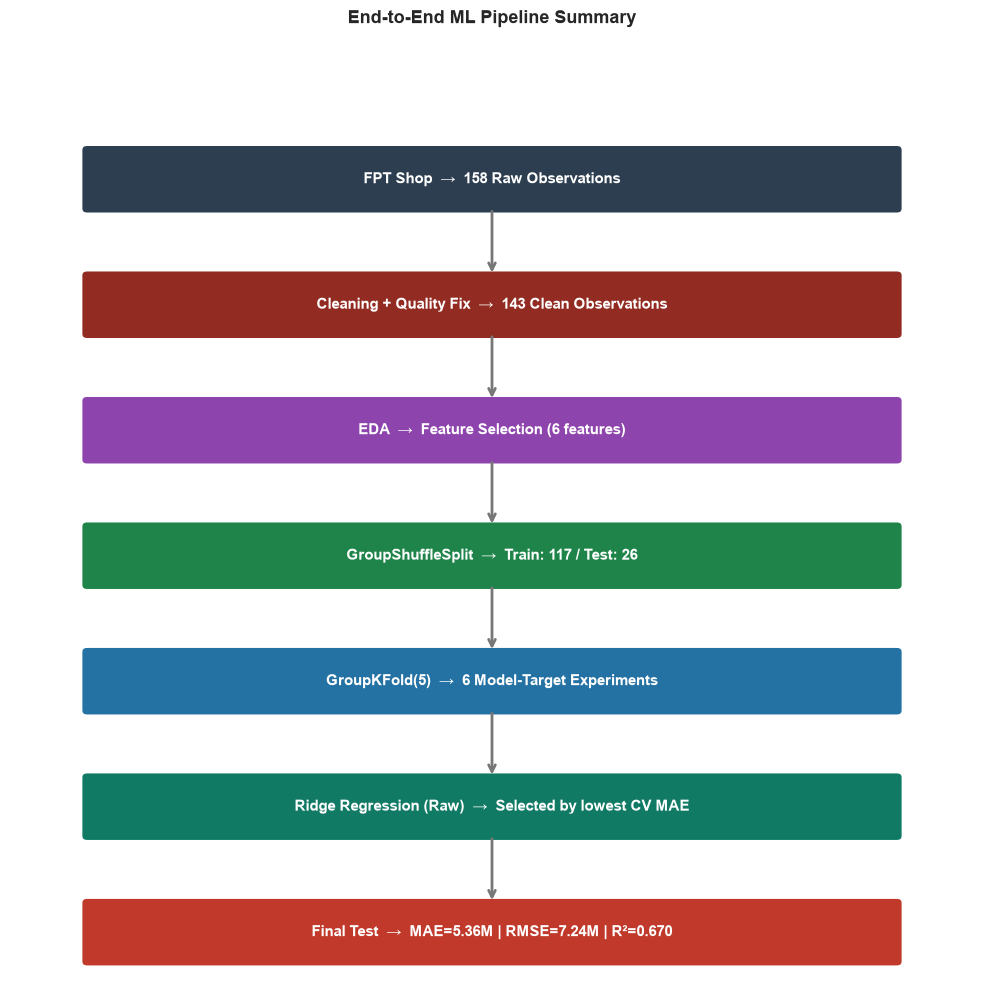

In [27]:
summary_stages = [
    ('#2c3e50', f'FPT Shop  →  {len(df_raw)} Raw Observations'),
    ('#922b21', f'Cleaning + Quality Fix  →  {len(df_clean)} Clean Observations'),
    ('#8e44ad', 'EDA  →  Feature Selection (6 features)'),
    ('#1e8449', f'GroupShuffleSplit  →  Train: {len(X_train)} / Test: {len(X_test)}'),
    ('#2471a3', 'GroupKFold(5)  →  6 Model-Target Experiments'),
    ('#117a65', f'Ridge Regression (Raw)  →  Selected by lowest CV MAE'),
    ('#c0392b', f'Final Test  →  MAE={fmt_m(test_mae_v)} | RMSE={fmt_m(test_rmse_v)} | R²={test_r2_v:.3f}'),
]

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, 10); ax.set_ylim(0, len(summary_stages)*1.6); ax.axis('off')

for i, (color, label) in enumerate(summary_stages):
    y = (len(summary_stages)-1-i) * 1.5 + 0.5
    rect = mpatches.FancyBboxPatch((0.8, y-0.35), 8.4, 0.7,
                                    boxstyle='round,pad=0.06',
                                    facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(5.0, y, label, ha='center', va='center', color='white',
            fontsize=10.5, fontweight='bold')
    if i < len(summary_stages)-1:
        y_next = (len(summary_stages)-2-i)*1.5 + 0.5
        ax.annotate('', xy=(5.0, y_next+0.35), xytext=(5.0, y-0.35),
                    arrowprops=dict(arrowstyle='->', color='#777', lw=2))

ax.set_title('End-to-End ML Pipeline Summary', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()


---
### Conclusion

| Question | Answer |
|---|---|
| **What was built?** | Smartphone Price Prediction Regression Model (V1 Baseline) |
| **Best model** | Ridge Regression (α=1.0, Raw target) |
| **ML vs Baseline** | CV MAE ~4.1M vs Dummy ~10.5M — model học được signal có ý nghĩa |
| **Structural limitation** | Thiếu Chipset, Generation, Display Technology — không phân biệt tốt Flagship vs Mid-range |
| **Negative predictions** | 2 observations (giá rẻ nhất) — inhérent với Linear/Ridge on Raw target |
| **Next steps** | Thu thập thêm dữ liệu; bổ sung features Chipset/Release Year; thử XGBoost cho V2 |